In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.linear_model import LinearRegression, LassoCV 
from sklearn.ensemble import RandomForestRegressor 
from catboost import CatBoostRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [4]:
print ("Размерность исходных данных: ", df.shape) 

Размерность исходных данных:  (21613, 21)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [6]:
df['date'] = df['date'].str[:4].astype(int)
df['date'].head()
df['date'].dtype

dtype('int64')

In [7]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21613 non-null  int64  
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_living15  21

In [9]:
df.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,2014.322954,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,0.467616,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,2014.000000,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2014.000000,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,2014.000000,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,2015.000000,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,2015.000000,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [10]:
miss_value = df.isnull().sum().sort_values(ascending=False)
print(miss_value[miss_value > 0])

Series([], dtype: int64)


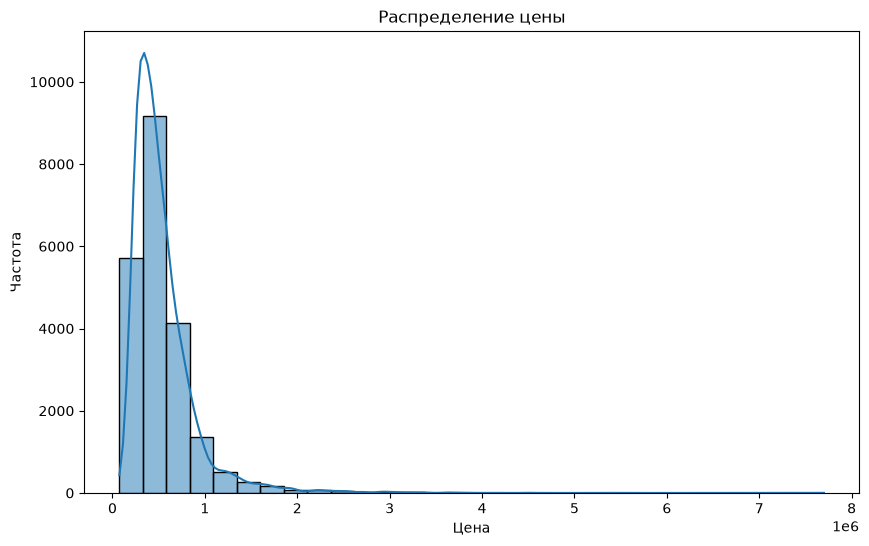

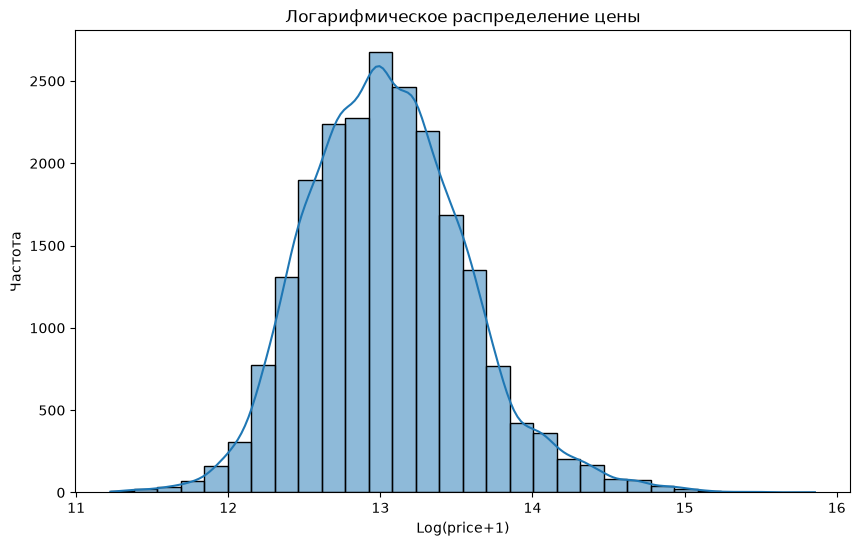

In [11]:
if "price" in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df["price"], kde=True, bins=30)
    plt.title("Распределение цены")
    plt.xlabel("Цена")
    plt.ylabel("Частота")
    plt.show()

    plt.figure(figsize=(10,6))
    sns.histplot(np.log1p(df["price"]), kde=True, bins=30)
    plt.xlabel("Log(price+1)")
    plt.ylabel("Частота")
    plt.title("Логарифмическое распределение цены")
    plt.show()
else:
    print("Нет столбца цены")

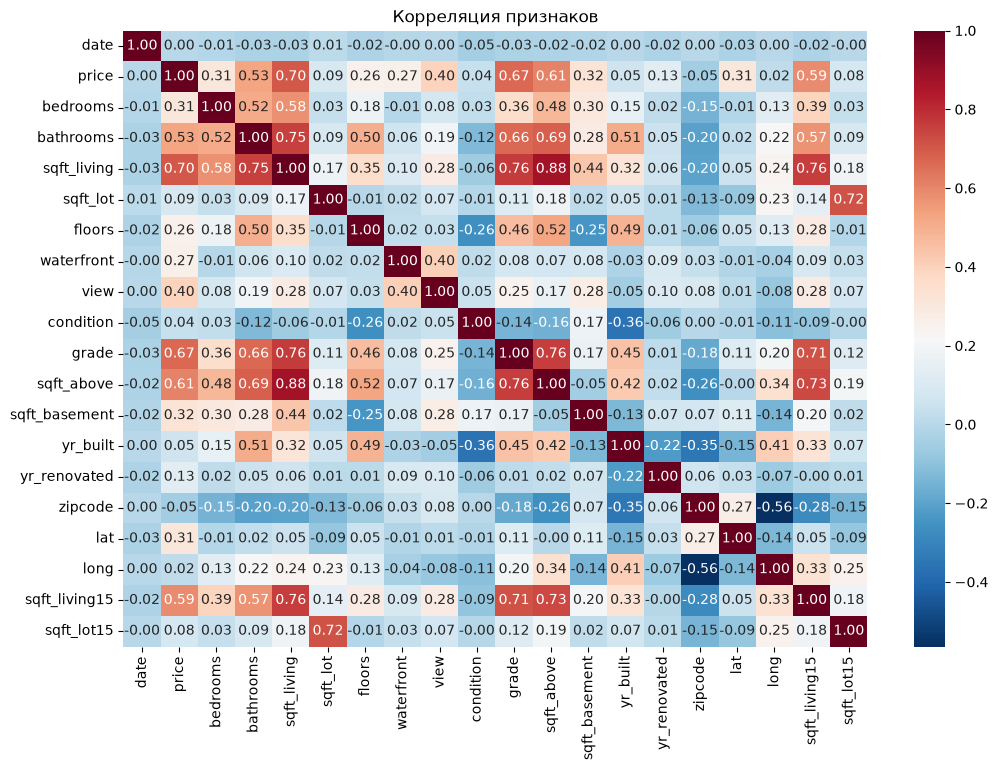

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
date             0.003576
zipcode         -0.053203
Name: price, dtype: float64


In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

if "price" in df.columns:
    corr_target = corr_matrix["price"].sort_values(ascending=False)
    print(corr_target)


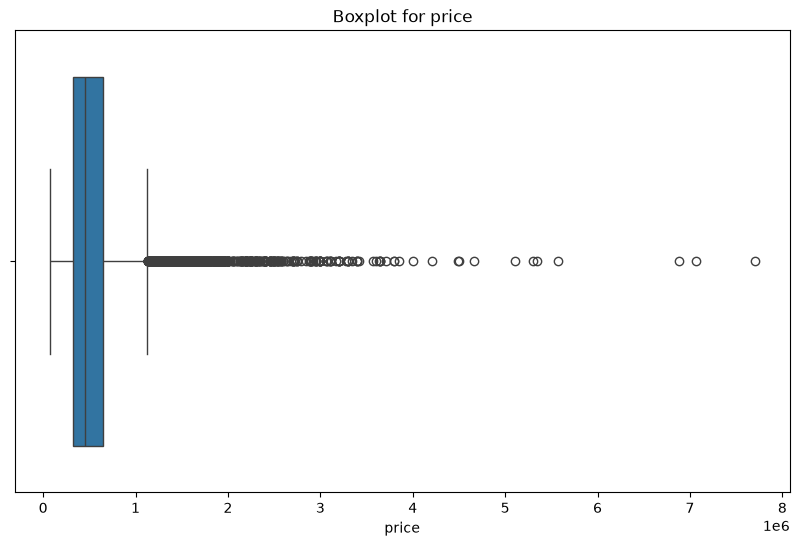

In [13]:
if "price" in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df["price"])
    plt.title("Boxplot for price")
    plt.show()

In [14]:
if "price" in df.columns:
    X = df.drop(columns = ["price"])
    y = df["price"]
    
    imputer = SimpleImputer(strategy="median")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    if X_imputed.isnull().sum().sum() == 0:
        print("\nПропущенных значений в датафрейме не обнаружено после заполнения.")
    else:
        print("\nОстались пропуски после заполнения!")
else:
    print("Столбец 'SalePrice' отсутствует. Невозможно продолжить.")


Пропущенных значений в датафрейме не обнаружено после заполнения.


In [15]:
if "price" in df.columns:
    lasso = LassoCV(cv=5, random_state=10)
    lasso.fit(X_imputed, y)

    coef = pd.Series(lasso.coef_, index=X_imputed.columns)
    selected_features = coef[coef != 0].index.tolist()
    print("\nНенулевые коэффициенты Lasso:")
    print(coef[coef != 0].sort_values(ascending=False))
    print("\nОтобранные признаки для модели:", selected_features)
else:
    print("SalePrice отсутствует, отбор признаков невозможен.")


Ненулевые коэффициенты Lasso:
sqft_living      237.205685
zipcode           96.299890
sqft_living15     80.575859
yr_renovated      69.778092
sqft_basement     14.570042
sqft_lot           0.074665
sqft_lot15        -0.760240
yr_built        -367.698927
dtype: float64

Отобранные признаки для модели: ['sqft_living', 'sqft_lot', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15']


In [16]:
if "price" in df.columns and len(selected_features)>0:
    X_selected = X_imputed[selected_features]
    X_train, X_test, y_train, y_test = train_test_split (X_selected, y, test_size=0.3, random_state=10)
    print("\nРазмерности выборок:")
    print("X_train:", X_train.shape, "| X_test:", X_test.shape)
else:
    print("Невозможно разделить данные без 'SalePrice' или без отобранных признаков.")


Размерности выборок:
X_train: (15129, 8) | X_test: (6484, 8)


In [17]:
lr_model = LinearRegression()
neg_mse_lr = cross_val_score(lr_model, X_train, y_train, cv = 5, scoring = "neg_mean_squared_error")
lr_rmse_cv = np.sqrt(-neg_mse_lr)
print("\nЛинейная регрессия - среднее кросс-валидационное RMSE:", lr_rmse_cv.mean())

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Линейная регрессия - тестовое RMSE:", rmse_lr)


Линейная регрессия - среднее кросс-валидационное RMSE: 247648.32391600078
Линейная регрессия - тестовое RMSE: 249228.7362274671


In [18]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\nЛинейная регрессия метрики:") 
print(f"Средняя абсолютная ошибка (MAE): {mae_lr:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse_lr:.2f}") 
print(f"Коэффициент детерминации (R²): {r2_lr:.2f}")


Линейная регрессия метрики:
Средняя абсолютная ошибка (MAE): 164223.76
Среднеквадратичная ошибка (MSE): 62114962961.54
Коэффициент детерминации (R²): 0.55


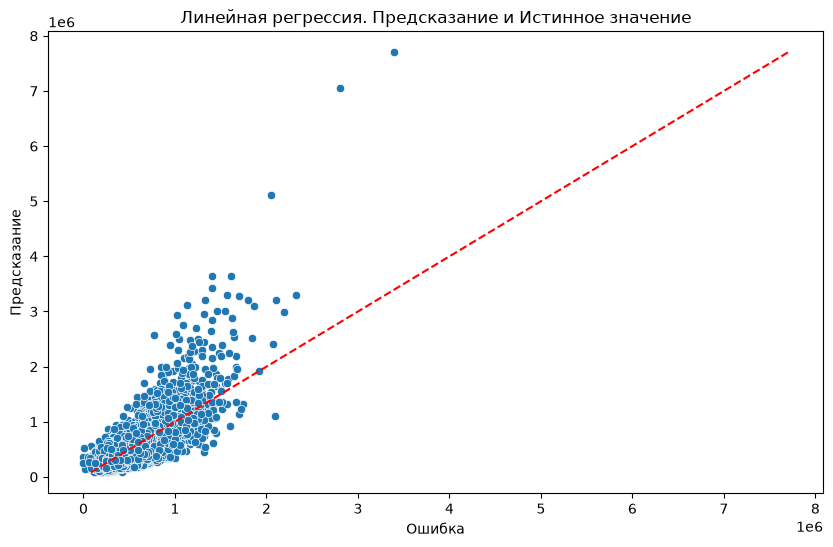

In [19]:
plt.figure(figsize = (10,6))
sns.scatterplot(x=y_pred_lr, y=y_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Линейная регрессия. Предсказание и Истинное значение")
plt.xlabel("Ошибка")
plt.ylabel("Предсказание")
plt.show()

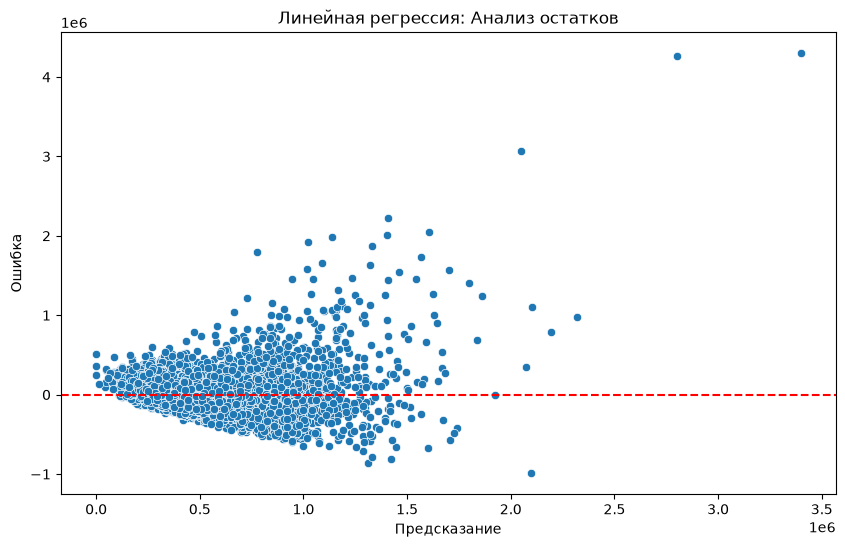

In [20]:
plt.figure(figsize = (10,6))
sns.scatterplot(x=y_pred_lr, y=y_test - y_pred_lr)
plt.axhline(0, color = "red", linestyle = "--")
plt.xlabel("Предсказание")
plt.ylabel("Ошибка")
plt.title("Линейная регрессия: Анализ остатков")
plt.show()

In [21]:
random_forest = RandomForestRegressor(random_state=10)
param_grid_rf = {
    "n_estimators": [100,200],
    "max_depth": [None, 8, 12],
    "min_samples_split": [2, 5]
}
grid_search_rf = GridSearchCV(random_forest, param_grid_rf, cv = 5, scoring = "neg_mean_squared_error", n_jobs = -1) #jobs - use all ядра процессора
grid_search_rf.fit(X_train, y_train)
print("\nЛучшая конфигурация случайного леса:")
print(grid_search_rf.best_params_)



Лучшая конфигурация случайного леса:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [22]:
best_rf = grid_search_rf.best_estimator_ 
y_pred_rf = best_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Случайный лес - тестовое RMSE:", rmse_rf)
print(f"\nСлучайный лес метрики:")
print(f"Средняя абсолютная ошибка (MAE): {mae_rf:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse_rf:.2f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse_rf:.2f}")
print(f"Коэффициент детерминации (R²): {r2_rf:.2f}")

Случайный лес - тестовое RMSE: 169762.7964734891

Случайный лес метрики:
Средняя абсолютная ошибка (MAE): 92949.47
Среднеквадратичная ошибка (MSE): 28819407066.50
Корень из среднеквадратичной ошибки (RMSE): 169762.80
Коэффициент детерминации (R²): 0.79


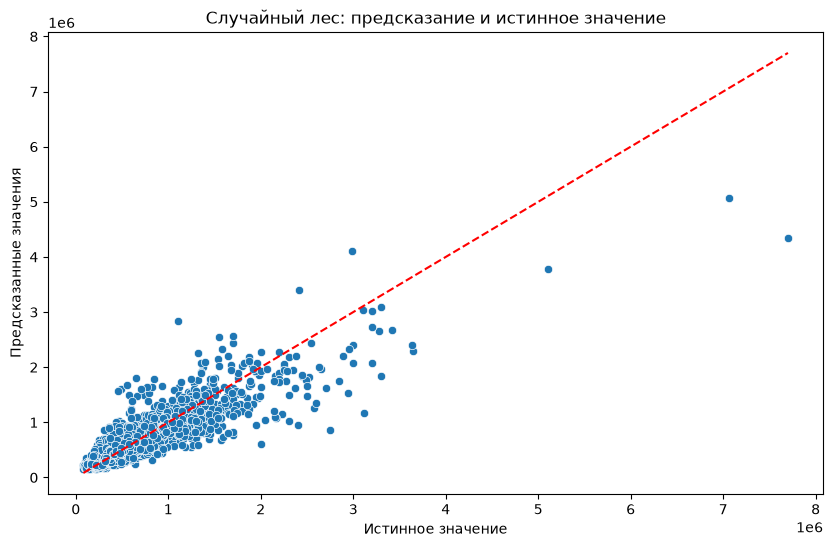

In [23]:
plt.figure(figsize = (10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], "r--")
plt.title("Случайный лес: предсказание и истинное значение")
plt.xlabel("Истинное значение")
plt.ylabel("Предсказанные значения")
plt.show()


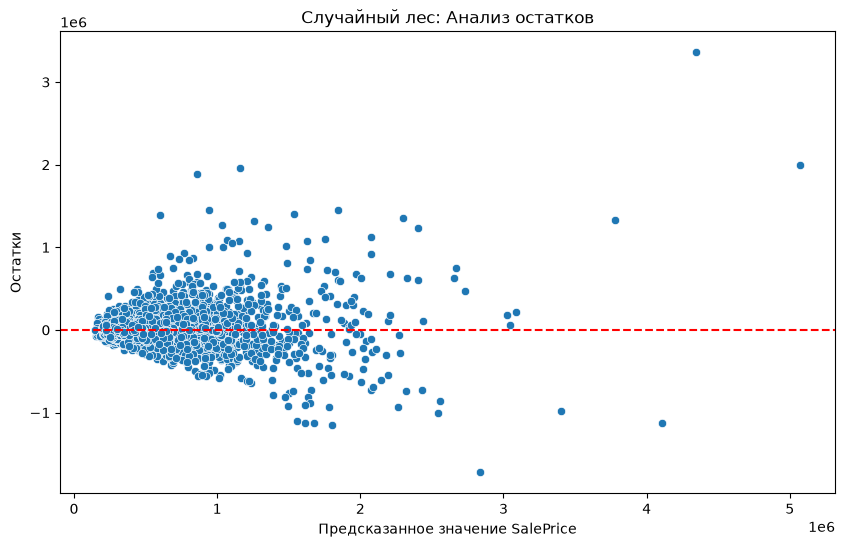

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=y_test - y_pred_rf)
plt.xlabel("Предсказанное значение SalePrice")
plt.ylabel("Остатки")
plt.axhline(0, color="red", linestyle="--")
plt.title("Случайный лес: Анализ остатков")
plt.show()

In [25]:
cat_model = CatBoostRegressor(
    iterations = 500,
    learning_rate = 0.1,
    random_state = 10,
    verbose = 2
)
neg_mse_cat = cross_val_score(cat_model, X_train, y_train, cv = 5, scoring = "neg_mean_squared_error")
cat_rmse_cv = np.sqrt(-neg_mse_cat)

cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
print("CatBoost - тестовое RMSE:", rmse_cat)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"\nCatBoost метрики:")
print(f"Средняя абсолютная ошибка (MAE): {mae_cat:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse_cat:.2f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse_cat:.2f}")
print(f"Коэффициент детерминации (R²): {r2_cat:.2f}")

0:	learn: 349787.1715512	total: 144ms	remaining: 1m 11s
2:	learn: 320748.5631400	total: 153ms	remaining: 25.4s
4:	learn: 298835.1681905	total: 162ms	remaining: 16s
6:	learn: 281318.8104455	total: 168ms	remaining: 11.8s
8:	learn: 267933.5707665	total: 173ms	remaining: 9.45s
10:	learn: 256240.1797029	total: 177ms	remaining: 7.89s
12:	learn: 247466.1541643	total: 181ms	remaining: 6.79s
14:	learn: 240827.7798138	total: 185ms	remaining: 5.99s
16:	learn: 233914.3405333	total: 189ms	remaining: 5.38s
18:	learn: 227827.5310145	total: 193ms	remaining: 4.89s
20:	learn: 223347.6943850	total: 197ms	remaining: 4.5s
22:	learn: 220110.9256053	total: 201ms	remaining: 4.18s
24:	learn: 214976.9357773	total: 206ms	remaining: 3.91s
26:	learn: 211278.9740189	total: 209ms	remaining: 3.67s
28:	learn: 208463.8530700	total: 213ms	remaining: 3.46s
30:	learn: 205381.8248123	total: 217ms	remaining: 3.28s
32:	learn: 202795.0124699	total: 221ms	remaining: 3.13s
34:	learn: 200711.6414445	total: 225ms	remaining: 2.99s

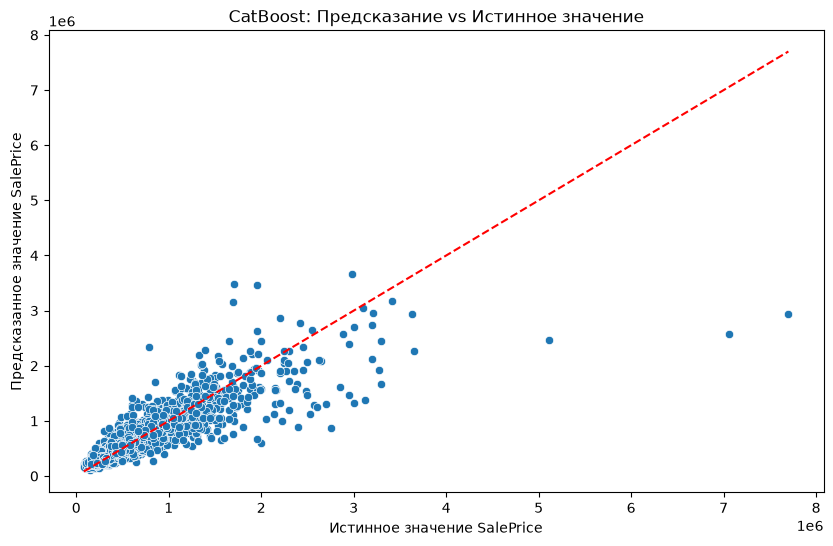

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_cat)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Истинное значение SalePrice")
plt.ylabel("Предсказанное значение SalePrice")
plt.title("CatBoost: Предсказание vs Истинное значение")
plt.show()

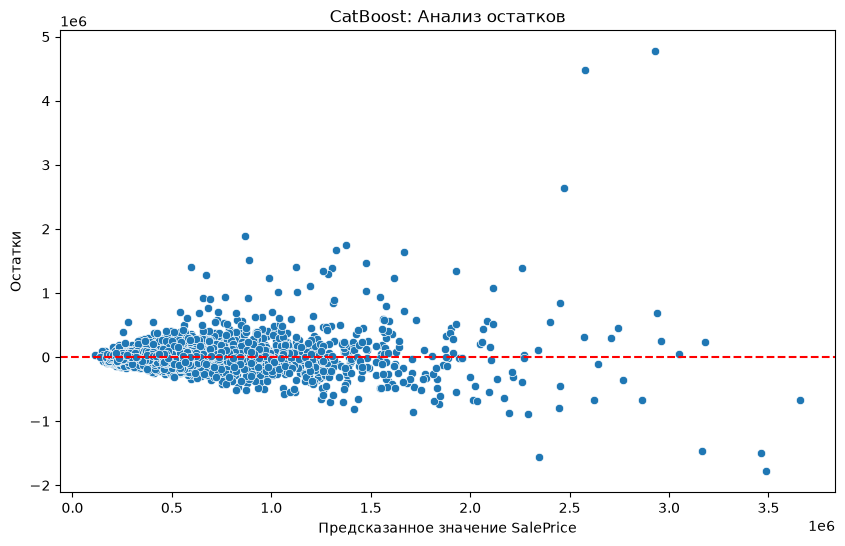

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_cat, y=y_test - y_pred_cat)
plt.xlabel("Предсказанное значение SalePrice")
plt.ylabel("Остатки")
plt.axhline(0, color="red", linestyle="--")
plt.title("CatBoost: Анализ остатков")
plt.show()

In [28]:
print("\n--- Итоговые метрики моделей ---")
print(f"Линейная регрессия: MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.2f}")
print(f"Случайный лес: MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")
print(f"CatBoost: MAE: {mae_cat:.2f}, MSE: {mse_cat:.2f}, RMSE: {rmse_cat:.2f}, R²: {r2_cat:.2f}")



--- Итоговые метрики моделей ---
Линейная регрессия: MAE: 164223.76, MSE: 62114962961.54, RMSE: 249228.74, R²: 0.55
Случайный лес: MAE: 92949.47, MSE: 28819407066.50, RMSE: 169762.80, R²: 0.79
CatBoost: MAE: 86750.46, MSE: 31388939750.56, RMSE: 177169.24, R²: 0.77


Лучшая модель - Случайный лес